In [35]:
import os
import itertools
import numpy as np
import math
import matplotlib.pyplot as plt
import time

In [36]:
grid30 = np.array([
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0],
 [0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0],
 [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1],
 [1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1],
 [1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1],
 [1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
 [0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,1,0,0,0,0,0,0],
 [0,0,0,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0,1,0],
 [0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,1,1,1,0,0,0,1,0,0,1,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
 [1,0,0,0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1],
 [0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0],
 [0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1],
 [0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,1,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0],
], dtype=np.int8)

In [37]:
# Kiểm tra điểm có nằm trong lưới không
def in_bounds(p, n, m):
    return 0 <= p[0] < n and 0 <= p[1] < m

# ---------- helpers ----------
MOVES8 = [(-1,-1), (-1,0), (-1,1),
          ( 0,-1),          ( 0,1),
          ( 1,-1), ( 1,0),  ( 1,1)]

# Hàm khoảng cách Euclid giữa hai điểm
def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

# Tính độ dài đường đi
def path_length(path):
    if not path or len(path) < 2:
        return 0.0
    return sum(euclid(path[i], path[i + 1]) for i in range(len(path) - 1))

In [38]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_path(grid, path, mandatory_waypoints):
    if path:
        print("\nĐường đi được trích xuất:")
        print(path)
        L_q = path_length(path)
        print("Độ dài đường đi:", round(L_q, 3))

        # Trực quan hóa đường đi Q-Learning
        print("\nĐang trực quan hóa đường đi Q-Learning...")
        fig, ax = plt.subplots(figsize=(8, 8))

        # Vẽ bản đồ (0=free, 1=obstacle)
        # Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
        im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

        # Vẽ đường đi theo từng bước
        xs = [p[1] for p in path] # Hoán đổi x và y để vẽ
        ys = [p[0] for p in path] # Hoán đổi x và y để vẽ
        ax.plot(xs, ys, linewidth=2, color="red", zorder=3) # Sử dụng màu khác cho đường đi Q
        ax.scatter([path[0][1], path[-1][1]], # Hoán đổi x và y để vẽ
                [path[0][0], path[-1][0]], # Hoán đổi x và y để vẽ
                marker='x', s=160, linewidths=2.5, color="red", zorder=4)

        # Vẽ các điểm bắt buộc
        mandatory_wp_x = [wp[1] for wp in mandatory_waypoints]
        mandatory_wp_y = [wp[0] for wp in mandatory_waypoints]
        ax.scatter(mandatory_wp_x, mandatory_wp_y, marker='o', s=100, linewidths=2.5, color="blue", zorder=5, label="Điểm bắt buộc")

        # ======= THÊM LƯỚI Ô NGUYÊN  =======
        n, m = grid.shape
        ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
        ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')

        ax.set_title(f"Đường đi có độ dài={L_q:.2f}, số bước={len(path)-1}")
        ax.legend()

        plt.tight_layout()
        # out_path_q = "/mnt/data/q_learning_path.png"
        # plt.savefig(out_path_q, dpi=180)
        plt.show() # Hiển thị biểu đồ đường đi Q-Learning
        # plt.close(fig)
        # print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

    else:
        print("\nKhông thể trích xuất đường đi hợp lệ từ bảng Q.")

In [39]:
from typing import List, Tuple, Iterable, Set

Point = Tuple[int, int]

def get_inflection_and_mandatory_points(
    path,
    mandatory_waypoints,
    keep_duplicates: bool = False
) -> List[Point]:
    """
    Trả về danh sách các điểm gồm:
    - các inflection point trên path
    - hợp với mandatory_waypoints

    Thứ tự trả về: theo thứ tự xuất hiện trên path.

    Parameters
    ----------
    grid : List[List[int]]
        Grid ban đầu. Hàm này chưa cần dùng trực tiếp đến grid,
        nhưng giữ lại đúng interface để bạn mở rộng tiếp.
    path : List[Point]
        Đường đi ban đầu, ví dụ [(x1,y1), (x2,y2), ...]
    mandatory_waypoints : Iterable[Point]
        Các điểm bắt buộc phải giữ lại
    keep_duplicates : bool
        - False: mỗi tọa độ chỉ xuất hiện 1 lần trong kết quả
        - True : giữ nguyên nếu cùng một tọa độ xuất hiện nhiều lần trên path

    Returns
    -------
    List[Point]
        Danh sách các điểm cần giữ lại
    """

    if not path:
        return []

    mandatory_set: Set[Point] = set(mandatory_waypoints)

    # 1) Loại bỏ điểm trùng liên tiếp để tránh vector (0,0)
    compact_path = [path[0]]
    original_indices = [0]  # map vị trí compact_path -> vị trí trong path gốc

    for idx in range(1, len(path)):
        if path[idx] != compact_path[-1]:
            compact_path.append(path[idx])
            original_indices.append(idx)

    # 2) Tìm inflection point: đổi hướng khi vector trước != vector sau
    inflection_indices_in_original_path = set()

    for i in range(1, len(compact_path) - 1):
        prev_pt = compact_path[i - 1]
        curr_pt = compact_path[i]
        next_pt = compact_path[i + 1]

        v1 = (curr_pt[0] - prev_pt[0], curr_pt[1] - prev_pt[1])
        v2 = (next_pt[0] - curr_pt[0], next_pt[1] - curr_pt[1])

        if v1 != v2:
            inflection_indices_in_original_path.add(original_indices[i])

    # 3) Lấy hợp của inflection point và mandatory_waypoints
    result = []
    seen = set()

    for idx, pt in enumerate(path):
        if idx == 0 or idx == len(path) - 1 or idx in inflection_indices_in_original_path or pt in mandatory_set:
            if keep_duplicates:
                result.append(pt)
            else:
                if pt not in seen:
                    result.append(pt)
                    seen.add(pt)

    return result

In [40]:
path = [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 5), (2, 6), (3, 6), (4, 6), (4, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (4, 14), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15), (9, 15), (10, 15), (11, 15), (12, 14), (13, 13), (14, 12), (14, 11), (14, 10), (14, 9), (15, 8), (16, 7), (16, 6), (16, 5), (16, 4), (16, 5), (16, 6), (16, 7), (16, 8), (16, 9), (16, 10), (16, 11), (16, 12), (16, 13), (17, 14), (17, 15), (18, 15), (19, 15), (20, 14), (21, 15), (22, 16), (23, 17), (22, 18), (21, 19), (20, 20), (21, 20), (22, 20), (23, 20), (24, 21), (25, 22), (26, 23), (27, 24), (28, 25), (29, 26), (29, 27), (29, 28), (29, 29)]

mandatory_waypoints = [(4, 6), (4, 15), (16, 4), (12, 14), (20, 20), (20, 14), (23, 17), (17, 15)]


# grid chỉ truyền vào cho đủ interface
grid = grid30


Đường đi được trích xuất:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 5), (2, 6), (3, 6), (4, 6), (4, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (4, 14), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15), (9, 15), (10, 15), (11, 15), (12, 14), (13, 13), (14, 12), (14, 11), (14, 10), (14, 9), (15, 8), (16, 7), (16, 6), (16, 5), (16, 4), (16, 5), (16, 6), (16, 7), (16, 8), (16, 9), (16, 10), (16, 11), (16, 12), (16, 13), (17, 14), (17, 15), (18, 15), (19, 15), (20, 14), (21, 15), (22, 16), (23, 17), (22, 18), (21, 19), (20, 20), (21, 20), (22, 20), (23, 20), (24, 21), (25, 22), (26, 23), (27, 24), (28, 25), (29, 26), (29, 27), (29, 28), (29, 29)]
Độ dài đường đi: 76.527

Đang trực quan hóa đường đi Q-Learning...


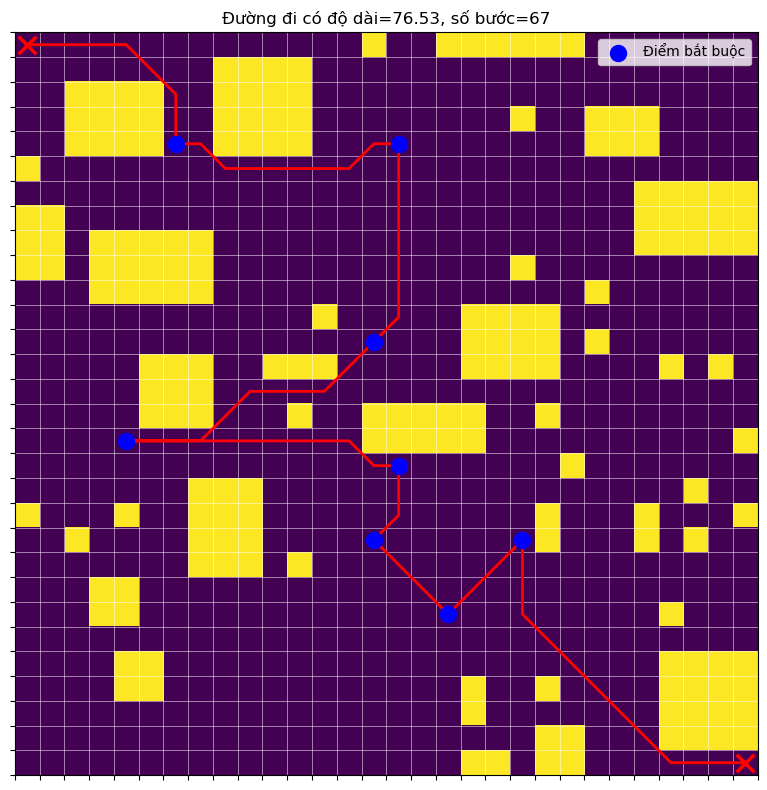

In [41]:
visualize_path(grid, path, mandatory_waypoints)

[(0, 0), (0, 4), (2, 6), (4, 6), (4, 7), (5, 8), (5, 13), (4, 14), (4, 15), (11, 15), (12, 14), (14, 12), (14, 9), (16, 7), (16, 4), (16, 13), (17, 14), (17, 15), (19, 15), (20, 14), (23, 17), (20, 20), (23, 20), (29, 26), (29, 29)]

Đường đi được trích xuất:
[(0, 0), (0, 4), (2, 6), (4, 6), (4, 7), (5, 8), (5, 13), (4, 14), (4, 15), (11, 15), (12, 14), (14, 12), (14, 9), (16, 7), (16, 4), (16, 13), (17, 14), (17, 15), (19, 15), (20, 14), (23, 17), (20, 20), (23, 20), (29, 26), (29, 29)]
Độ dài đường đi: 76.527

Đang trực quan hóa đường đi Q-Learning...


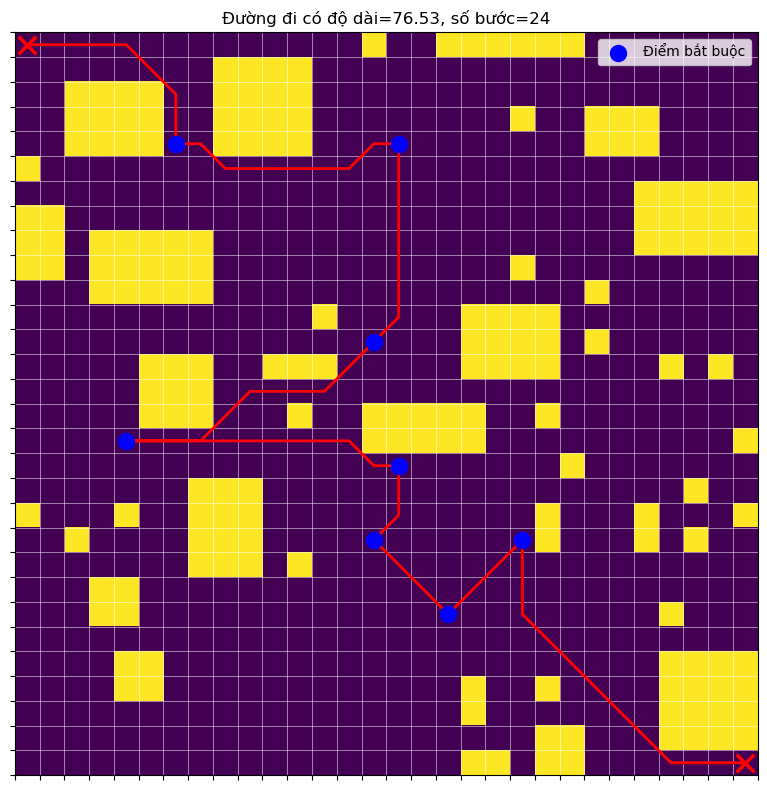

In [42]:
key_points = get_inflection_and_mandatory_points(
    path=path,
    mandatory_waypoints=mandatory_waypoints,
    keep_duplicates=False
)

print(key_points)
visualize_path(grid, key_points, mandatory_waypoints)